### This is the notebook for the variant effect baseline model
- I have a table with REF and ALT both column hold the information of the sequence name for the reference and the alternative respectively. I would like to merge the predictions from another file once for the REF and subsequently for the ALT column. 
1. Join variant_table with predictions left on REF and right on ID 
2. rename the columns and add a prefix "REF_" 
3. drop the column "REF_ID" Do the same with the ALT column (add prefix and drop column ALT_ID) 
4. After that I would like to compute the absolute difference between all columns starting with REF vs all columns starting with ALT 
5. plot a list of the top variants
- Idea: 
1. load variant map
2. enformer element predictions (inner join for reference and alternative)
3. Enformer prediction (absolute difference between all enformer predictions)
  - make it first only on the DNase predictions

In [40]:
import pandas as pd
import numpy as np
import yaml
# for the correlation plotting
import seaborn as sns
import matplotlib.pyplot as plt
# for the lasso regression
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
# -----

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

config_path = "../../global80K_config.yaml"
# load config file
with open(config_path, "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

1. load variant map
2. enformer element predictions (inner join for reference and alternative)

#### load variant table, enformer prediction table, bcalm variant predictions

In [ ]:
# load variant table and enformer prediction table
variant_table = pd.read_csv(config['files']['final_design']['variant_table'], sep="\t")
variant_map = variant_table.drop(columns=['Region']).copy()
variant_map.head()





,ID,REF,ALT
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...


In [35]:
#! Attention here are missing
# add variant effect from bcalm:
bcalm_bbmap_35_df = pd.read_csv(config['files']['creating']['bc_MPRAlm'], sep="\t")
bcalm_bbmap_35_df.head() # 38,364
variant_map_effect = variant_map.merge(bcalm_bbmap_35_df[['variant_id', 'logFC']], left_on='ID', right_on='variant_id', how='inner')
variant_map_effect.drop(columns=['variant_id'], inplace=True)
print(variant_map_effect.shape[0]) # 38205
variant_map_effect.head()

38205


,ID,REF,ALT,logFC
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.004829
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.074599
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.028610
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.060843
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.065858


In [ ]:
ref_seqs = set(variant_map['REF'].to_list())
alt_seqs = set(variant_map['ALT'].to_list())


,ID,REF,ALT
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
...,...,...,...
47039,C_positive_heart_CAD:rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618
47040,C_positive_heart_CAD:rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757
47041,C_positive_heart_CAD:rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373
47042,C_positive_heart_CAD:rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656


In [ ]:
# currently focus on 680/5k columns
enformer_sequence_predictions_path = '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/element_enformer_prediction/sequences_for_enformer_predictions_only_sequences_with_padding_680.tsv.gz'
all_cols_enformer_sequence_predictions_path = '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/element_enformer_prediction/ssequences_for_enformer_predictions_only_sequences_with_padding_all_columns.tsv.gz'
all_enformer_sequence_predictions_df = pd.read_csv(enformer_sequence_predictions_path, sep="\t") # 80215
all_enformer_sequence_predictions_df.columns.values[0] = 'sequence_ID'
all_enformer_sequence_predictions_df.head()


,sequence_ID,DNASE:cerebellum male adult (27 years) and male adult (35 years),DNASE:frontal cortex male adult (27 years) and male adult (35 years),DNASE:chorion,DNASE:Ishikawa treated with 0.02% dimethyl sulfoxide for 1 hour,DNASE:GM03348,DNASE:GM03348 genetically modified using transduction treated with 3 ug/mL doxycycline for 10 days,DNASE:AG08395,DNASE:AG08396,DNASE:AG20443,...,DNASE:inferior parietal cortex male adult (84 years),DNASE:kidney capillary endothelial cell female embryo (113 days),DNASE:placenta male embryo (91 day),DNASE:right kidney male embryo (115 days),DNASE:coronary artery female adult (51 year),ATAC:BM0106-Day0-MCP-A / Bone Marrow CD34+ / pDC,ATAC:BM0106-UNK-ATAC-2 / Bone Marrow CD34+ / UNK,ATAC:BM0828-MEGA1-A-151109 / Bone Marrow CD34+ / Mega,ATAC:BM1077-MCP / Bone Marrow CD34+ / pDC,ATAC:BM1077-UNK / Bone Marrow CD34+ / UNK
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1961,0.0943,0.1697,0.3024,0.1082,0.1418,0.1290,0.1539,0.2046,...,0.0463,0.1087,0.2370,0.1261,0.1644,2.3822,1.5600,3.0842,0.9669,1.1727
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1233,0.0770,0.0882,0.1016,0.0693,0.1034,0.0692,0.0897,0.1155,...,0.0313,0.0726,0.0726,0.0947,0.1309,1.8988,0.9468,1.4994,1.0074,1.0907
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.0222,0.0164,0.0198,0.0309,0.0163,0.0195,0.0206,0.0223,0.0275,...,0.0263,0.0566,0.0589,0.0745,0.0991,1.8352,0.9056,1.6134,0.6954,0.7274
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2126,0.0995,0.1080,0.2529,0.0863,0.1357,0.0901,0.1196,0.1660,...,0.0568,0.0999,0.1362,0.2760,0.1561,3.4291,1.2551,2.1055,5.2447,2.2171
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.1063,0.0846,0.1128,0.1429,0.0857,0.1218,0.1089,0.1085,0.1485,...,0.0459,0.1001,0.1138,0.1452,0.1629,2.4780,1.3756,3.0101,1.3488,1.7251


In [ ]:
# # Example data
# variant_table = pd.DataFrame({
#     'REF': ['A', 'B', 'C'],
#     'ALT': ['D', 'E', 'F']
# })

# predictions = pd.DataFrame({
#     'ID': ['A', 'B', 'C', 'D', 'E', 'F'],
#     'Score1': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
#     'Score2': [1.1, 1.2, 1.3, 1.4, 1.5, 1.6]
# })

# Merge for REF
ref_merged = variant_map_effect.merge(all_enformer_sequence_predictions_df, left_on='REF', right_on='sequence_ID', how='inner')
ref_merged.drop(columns=['sequence_ID'], inplace=True)
ref_merged = ref_merged.rename(columns=lambda x: f"REF_{x}" if x not in variant_map_effect.columns else x)
ref_merged
# # # Merge for ALT
alt_merged = ref_merged.merge(all_enformer_sequence_predictions_df, left_on='ALT', right_on='sequence_ID', how='inner')
alt_merged.drop(columns=['sequence_ID'], inplace=True)
alt_merged = alt_merged.rename(columns=lambda x: f"ALT_{x}" if x not in ref_merged.columns else x)
# alt_merged = alt_merged.drop(columns=['ALT_ID'])
alt_merged

# Compute absolute differences
ref_cols = [col for col in alt_merged.columns if col.startswith('REF_')]
alt_cols = [col for col in alt_merged.columns if col.startswith('ALT_')]
diffs = pd.DataFrame()

for ref, alt in zip(ref_cols, alt_cols):
    diff_col = f"diff_{ref.split('_', 1)[1]}"
    diffs[diff_col] = (alt_merged[ref] - alt_merged[alt]).abs()

# Add differences back to the table
alt_merged = pd.concat([alt_merged, diffs], axis=1)

# Focus on diff columns
alt_merged = alt_merged.loc[:, ~alt_merged.columns.str.startswith(('REF_', 'ALT_'))]
alt_merged # 38180

/tmp/ipykernel_343919/3640239710.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  diffs[diff_col] = (alt_merged[ref] - alt_merged[alt]).abs()
/tmp/ipykernel_343919/3640239710.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  diffs[diff_col] = (alt_merged[ref] - alt_merged[alt]).abs()
/tmp/ipykernel_343919/3640239710.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax

,ID,REF,ALT,logFC,diff_DNASE:cerebellum male adult (27 years) and male adult (35 years),diff_DNASE:frontal cortex male adult (27 years) and male adult (35 years),diff_DNASE:chorion,diff_DNASE:Ishikawa treated with 0.02% dimethyl sulfoxide for 1 hour,diff_DNASE:GM03348,diff_DNASE:GM03348 genetically modified using transduction treated with 3 ug/mL doxycycline for 10 days,...,diff_DNASE:inferior parietal cortex male adult (84 years),diff_DNASE:kidney capillary endothelial cell female embryo (113 days),diff_DNASE:placenta male embryo (91 day),diff_DNASE:right kidney male embryo (115 days),diff_DNASE:coronary artery female adult (51 year),diff_ATAC:BM0106-Day0-MCP-A / Bone Marrow CD34+ / pDC,diff_ATAC:BM0106-UNK-ATAC-2 / Bone Marrow CD34+ / UNK,diff_ATAC:BM0828-MEGA1-A-151109 / Bone Marrow CD34+ / Mega,diff_ATAC:BM1077-MCP / Bone Marrow CD34+ / pDC,diff_ATAC:BM1077-UNK / Bone Marrow CD34+ / UNK
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.004829,0.0458,0.0376,0.0789,0.0339,0.2573,0.1536,...,0.0231,0.1350,0.4623,0.3295,0.0557,0.0319,0.0474,5.0713,0.0299,0.0501
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.074599,0.0031,0.0005,0.0002,0.0011,0.0008,0.0013,...,0.0000,0.0007,0.0049,0.0021,0.0006,0.0124,0.0518,0.0708,0.0288,0.0167
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.028610,0.0047,0.0009,0.0091,0.0529,0.0058,0.0058,...,0.0007,0.0597,0.1033,0.0446,0.0067,0.2927,0.0194,2.6388,1.0893,0.0030
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.060843,0.0016,0.0160,0.0095,0.0051,0.0209,0.0400,...,0.0094,0.0475,0.0225,0.0780,0.0073,0.6766,1.5358,14.4677,2.0782,1.4369
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.065858,0.0077,0.0113,0.0175,0.0267,0.0112,0.0126,...,0.0116,0.0300,0.0471,0.0383,0.0077,0.3404,0.8261,8.2239,0.7541,0.7605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38175,C_positive_heart_CAD:rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618,0.146110,0.0017,0.0008,0.0002,0.0012,0.0001,0.0003,...,0.0019,0.0043,0.0003,0.0003,0.0001,0.0116,0.0311,0.1019,0.0423,0.0398
38176,C_positive_heart_CAD:rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757,-0.169500,0.0003,0.0001,0.0000,0.0002,0.0000,0.0001,...,0.0001,0.0004,0.0006,0.0002,0.0010,0.0060,0.0045,0.0810,0.0148,0.0013
38177,C_positive_heart_CAD:rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373,0.131226,0.0007,0.0010,0.0103,0.0364,0.0874,0.0812,...,0.0008,0.0133,0.0170,0.0072,0.0014,0.0446,0.0264,0.7971,0.0874,0.0404
38178,C_positive_heart_CAD:rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656,0.061286,0.0052,0.0052,0.0093,0.0063,0.0054,0.0071,...,0.0016,0.0242,0.0118,0.0039,0.0081,0.1086,0.0665,0.1899,0.1309,0.0861


### Prepare for lasso regression
- add bcalm logFC (measured_effect)

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.09357537008196459, tolerance: 0.0316011830896791
  model = cd_fast.enet_coordinate_descent_gram(
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1715863348459834, tolerance: 0.0316011830896791
  model = cd_fast.enet_coordinate_descent_gram(
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.2541031982559616, tolerance: 0.0316011830896791
  model = cd_fast.enet_coordinate_descent_gram(
/home/kisa/miniforge3/envs/mobil/

Feature Importance:
diff_DNASE:K562 G1 phase                                                                                   0.000530
diff_DNASE:MCF-7 originated from MCF-7                                                                     0.000082
diff_DNASE:medulloblastoma                                                                                 0.001240
diff_DNASE:T47D treated with 10 nM 17B-estradiol for 30 minutes                                            0.000172
diff_DNASE:SK-MEL-5                                                                                        0.001355
diff_DNASE:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days    0.000255
dtype: float64


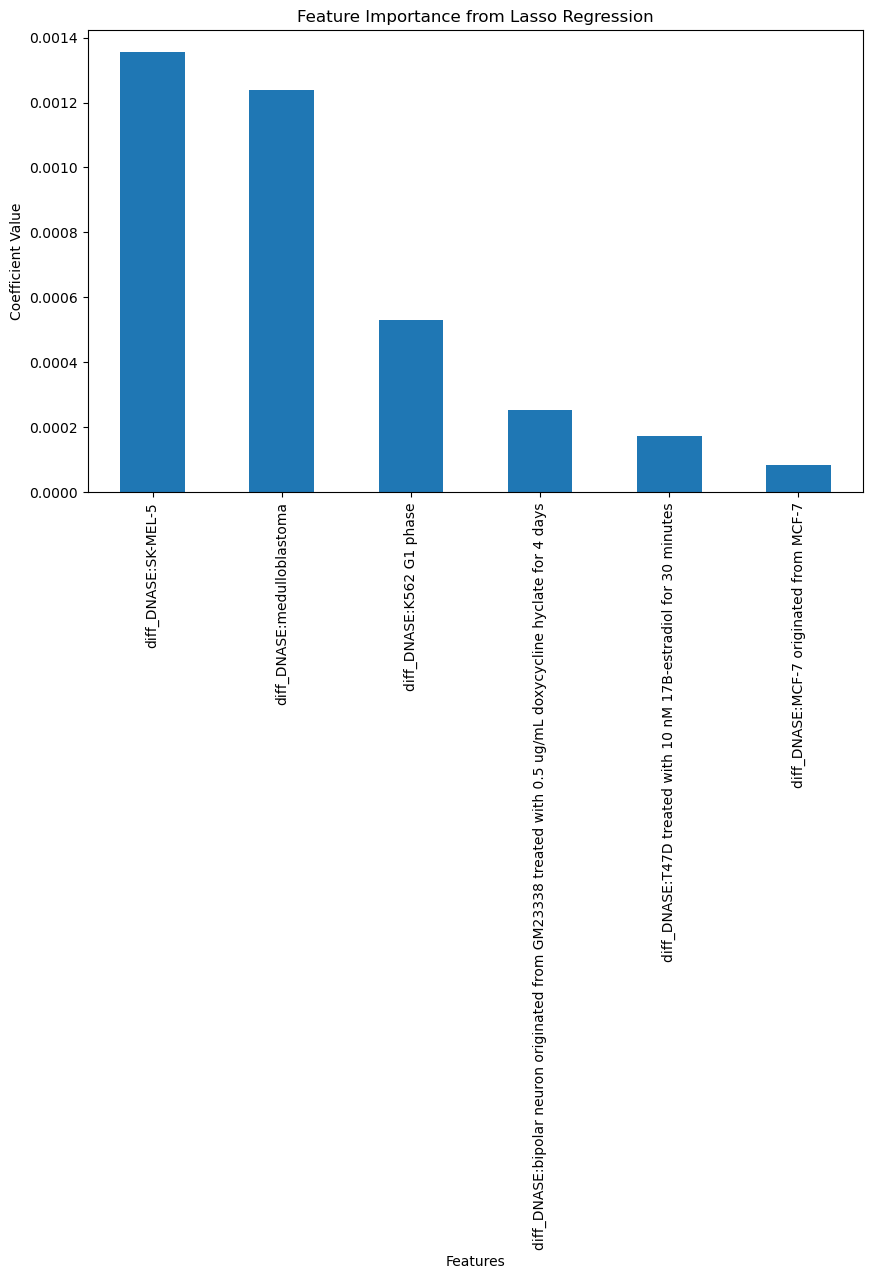

R^2 Score: 0.002


In [50]:
# Features (diff_* columns) and target
X = alt_merged.filter(like="diff_")
y = alt_merged['logFC']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform Lasso regression with cross-validation
lasso = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_scaled, y)

# Extract feature importance
feature_importance = pd.Series(lasso.coef_, index=X.columns)
important_features = feature_importance[feature_importance != 0]

# Display feature importance
print("Feature Importance:")
print(important_features)

# Plot feature importance
plt.figure(figsize=(10, 6))
important_features.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance from Lasso Regression")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.show()

# Evaluate model performance
r2_score = lasso.score(X_scaled, y)
print(f"R^2 Score: {r2_score:.3f}")
# ENCFF810XTS
# diff_DNASE:SK-MEL-5                                                                                        0.001355
# diff_DNASE:medulloblastoma                                                                                 0.001240
# diff_DNASE:K562 G1 phase                                                                                   0.000530
# diff_DNASE:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days    0.000255
# diff_DNASE:T47D treated with 10 nM 17B-estradiol for 30 minutes                                            0.000172
# diff_DNASE:MCF-7 originated from MCF-7                                                                     0.000082

In [44]:
important_features.sum()

0.0036327372623788843

In [ ]:
# Paths for saving the files
important_features_path = "/path/to/important_features.csv"  # Adjust path as needed
r2_score_path = "/path/to/r2_score.txt"
plot_path = "/path/to/lasso_feature_importance.png"

# Save feature importance to CSV
feature_importance.to_csv(important_features_path, header=["Coefficient"])

# Save R^2 score to a text file
with open(r2_score_path, "w") as file:
    file.write(f"R^2 Score: {r2_score:.3f}")

# Create and save the feature importance plot
plt.figure(figsize=(10, 6))
feature_importance.sort_values(ascending=False).plot(
    kind='bar',
    color=(feature_importance > 0).map({True: 'green', False: 'red'})
)
plt.title("Feature Importance from Lasso Regression (Positive and Negative)")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Horizontal line at 0
plt.tight_layout()
plt.savefig(plot_path)
plt.close()

print(f"Feature importance saved to: {important_features_path}")
print(f"R^2 score saved to: {r2_score_path}")
print(f"Feature importance plot saved to: {plot_path}")

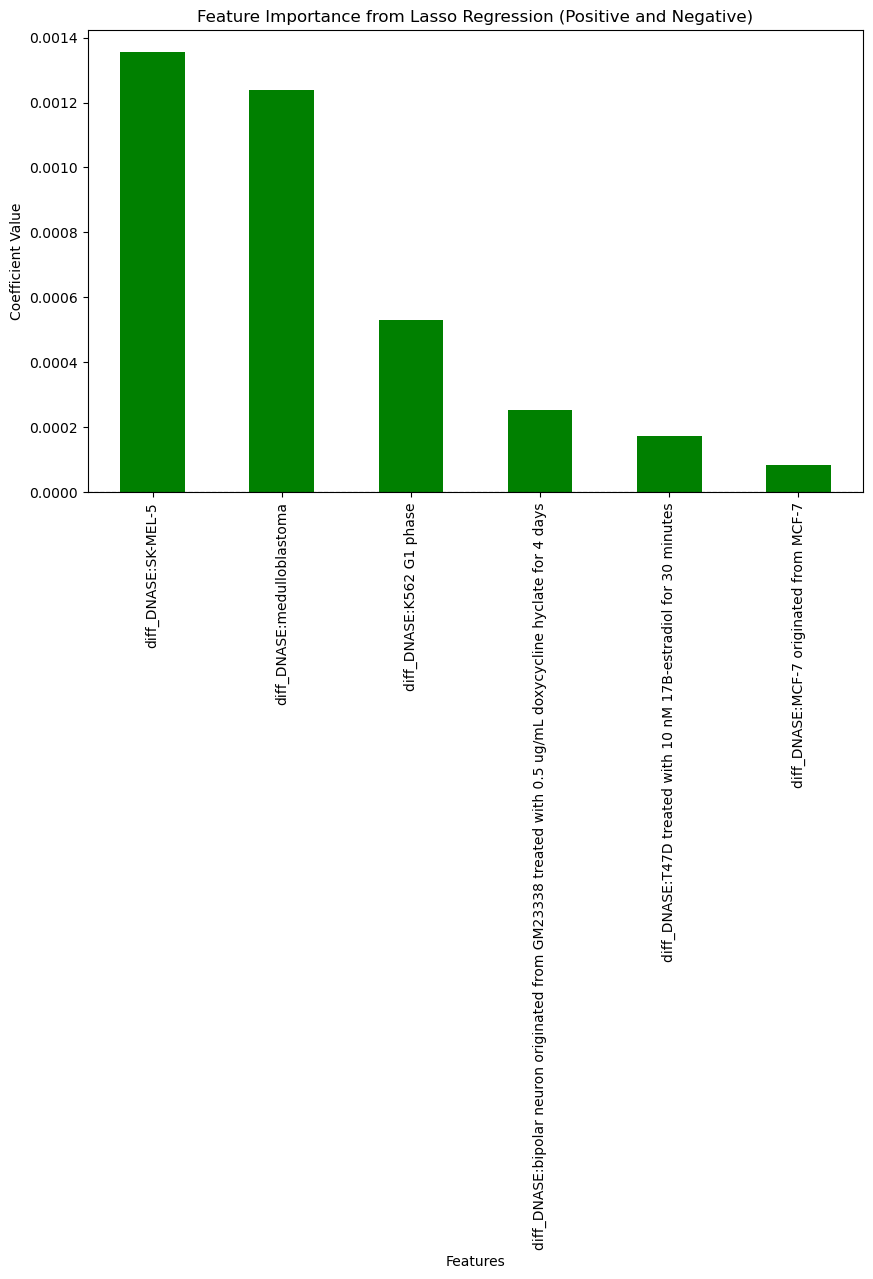

In [49]:
# Plot all non-zero coefficients, sorted by value (positive and negative)
plt.figure(figsize=(10, 6))
important_features.sort_values(ascending=False).plot(kind='bar', color=(important_features > 0).map({True: 'green', False: 'red'}))
plt.title("Feature Importance from Lasso Regression (Positive and Negative)")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Add a horizontal line at 0
plt.show()